<a href="https://colab.research.google.com/github/F-Boivin/ProyectoDSParte1-Felipe-Boivin/blob/main/ProyectoDSParte1_Felipe_Boivin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Data Science I — Parte I
## Análisis exploratorio del dataset UCI Bank Marketing

**Alumno:** Felipe Boivin

**Curso:** Data Science I — Comisión 90505

**Fecha de entrega:** 03/03/2026

**Dataset:** [bank.csv — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

## Abstract

El presente trabajo tiene como objetivo realizar un análisis exploratorio de datos (EDA) sobre el dataset "Bank Marketing", disponible en el repositorio UCI Machine Learning Repository. Este conjunto de datos contiene información relacionada con campañas de marketing telefónico llevadas a cabo por una institución bancaria portuguesa, cuyo fin era promover la contratación de depósitos a plazo fijo entre sus clientes.

El dataset cuenta con 4521 registros y 17 variables que abarcan información demográfica de los clientes (edad, estado civil, nivel educativo, ocupación), su situación financiera (saldo en cuenta, si posee crédito hipotecario o préstamo personal) y datos relativos a la campaña de contacto (tipo de comunicación, día y mes del último contacto, duración de la llamada, cantidad de contactos realizados). También incluye información sobre campañas previas y una variable objetivo binaria que indica si el cliente contrató o no el depósito a plazo.

El análisis se estructura en torno a una pregunta problema central: ¿qué factores del perfil del cliente y de la estrategia de contacto influyen en la decisión de contratar un depósito a plazo fijo? Para responderla, se plantean cuatro hipótesis de interés: (H1) que los clientes casados presentan mayor tasa de contratación que los solteros, dado que se los suele asociar con mayor estabilidad financiera; (H2) que los clientes que contratan el depósito poseen un saldo promedio superior; (H3) que las llamadas de mayor duración se asocian con una mayor probabilidad de contratación; y (H4) que los clientes que tuvieron un resultado exitoso en campañas anteriores tienen mayor tendencia a volver a contratar.

A través de resúmenes numéricos y visualizaciones — incluyendo gráficos de barras agrupadas, boxplots e histogramas — se busca explorar estas relaciones, identificar patrones y evaluar si los datos respaldan o refutan cada hipótesis planteada. También se realizará una identificación de valores perdidos, tanto explícitos como encubiertos bajo la categoría "unknown" presente en algunas variables categóricas del dataset.

Este trabajo corresponde a la primera entrega del proyecto final del curso Data Science I de Coderhouse y sienta las bases para un análisis más profundo en etapas posteriores.

## Preguntas e hipótesis de interés

### Pregunta problema central

> ¿Qué factores del perfil del cliente y de la estrategia de contacto influyen en la decisión de contratar un depósito a plazo fijo?

### Hipótesis

**H1 — Estado civil y suscripción:**
Los clientes casados, al tener mayor estabilidad financiera, contratan el depósito en mayor proporción que los solteros.

**H2 — Saldo y contratación:**
Los clientes que contratan el depósito poseen un saldo promedio en cuenta significativamente mayor que los que no lo hacen.

**H3 — Duración de la llamada y resultado:**
Las llamadas de mayor duración se asocian con una mayor probabilidad de contratación del depósito.

**H4 — Resultado de campaña previa:**
Los clientes que tuvieron un resultado exitoso en campañas de marketing anteriores presentan mayor tendencia a contratar nuevamente.

## Importacion librerias y set de datos

In [1]:
# Importar librerías, Pandas y Matplotlib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Importar set de datos desde GITHUB
url = 'https://raw.githubusercontent.com/F-Boivin/ProyectoDSParte1-Felipe-Boivin/main/bank%20(1).csv'
df = pd.read_csv(url, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Exploracion inicial

In [3]:
# Dimensiones del dataset
print('Dimensiones del dataset:', df.shape)
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print()

# Tipos de dato por columna
print('Tipos de dato:')
print(df.dtypes)

Dimensiones del dataset: (4521, 17)
Filas: 4521 | Columnas: 17

Tipos de dato:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


## Analisis de valores perdidos

In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [5]:
# Verificación de nulos formales
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [6]:
# Detección de valores "unknown" en variables categóricas
categoricas = df.select_dtypes(include='object').columns

print('Cantidad y porcentaje de valores "unknown" por variable categórica:\n')
for col in categoricas:
    cant_unknown = (df[col] == 'unknown').sum()
    if cant_unknown > 0:
        porcentaje = round(cant_unknown / len(df) * 100, 2)
        print(f'  {col}: {cant_unknown} valores "unknown" ({porcentaje}%)')

Cantidad y porcentaje de valores "unknown" por variable categórica:

  job: 38 valores "unknown" (0.84%)
  education: 187 valores "unknown" (4.14%)
  contact: 1324 valores "unknown" (29.29%)
  poutcome: 3705 valores "unknown" (81.95%)


## Interpretacion valores perdidos
No se detectan valores nulos formales (NaN) en ninguna columna del dataset.

Sin embargo, al inspeccionar las variables categóricas se identifican valores "unknown" que representan datos faltantes encubiertos.
Estos se concentran en las variables contact, poutcome y education.

Poutcome presenta un alto porcentaje de valores desconocidos. En el dataset original, esta variable esta definida como "outcome of the previous marketing campaign", imagino que el alto porcentaje obedece a que se trataria de clientes que no fueron contactados en campañas anteriores.

# Resumen estadistico del dataset

In [7]:
# Estadísticos de variables numéricas
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [8]:
# Frecuencias de variables categóricas
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


## Interpretacion del resumen estadistico
* La edad promedio de los clientes es de aproximadamente 41 años, con un rango entre 19 y 87.
* El saldo en cuenta (balance) presenta gran dispersión: la media es cercana a 1423 pero la mediana (448) es mucho menor, lo que indica una distribución asimétrica con algunos clientes con saldos muy elevados.
* La duración promedio de las llamadas (duration) ronda los 264 segundos (~4.4 minutos), aunque también muestra alta variabilidad.
* En cuanto a las categóricas:
  * la ocupación más frecuente es management,
  * el estado civil predominante es married,
  * la variable objetivo 'y' muestra que la mayoría de los clientes no contrató el depósito.
  * Resulta llamativa la concentración de casos en el mes de mayo, que representa aproximadamente el 30% del total de registros del dataset. Esto sugiere que el banco intensificó significativamente sus campañas telefónicas durante ese mes. Sería interesante analizar si la tasa de contratación varía según el mes de contacto y si mayo, a pesar de concentrar más llamadas, mantiene una tasa de éxito comparable al resto de los meses.

## H1 — Estado civil y suscripción
**Hipótesis:** Los clientes casados, al tener mayor estabilidad financiera, contratan el depósito en mayor proporción que los solteros.

In [9]:
# Tabla cruzada: proporción de contratación por estado civil
ct_marital = pd.crosstab(df['marital'], df['y'], normalize='index') * 100
print(ct_marital.round(2))

y            no    yes
marital               
divorced  85.42  14.58
married   90.10   9.90
single    86.04  13.96


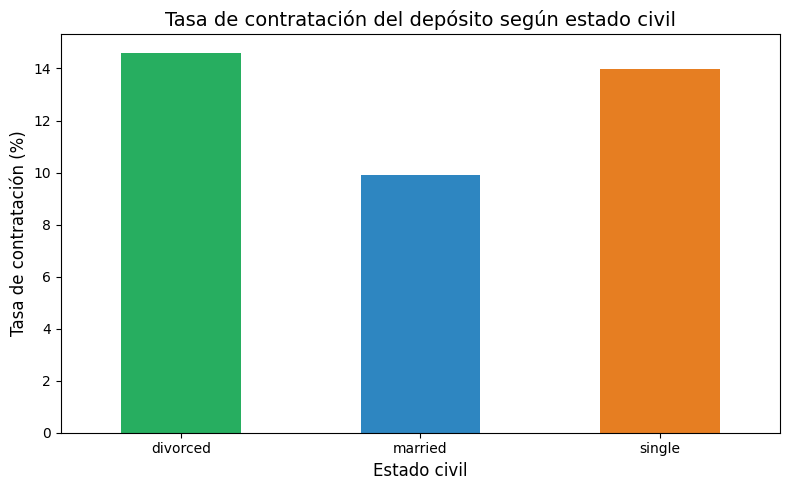

In [11]:
# Gráfico: tasa de contratación (%) por estado civil
tasa_yes = pd.crosstab(df['marital'], df['y'], normalize='index')['yes'] * 100

tasa_yes.plot(kind='bar', figsize=(8, 5), color=['#27ae60', '#2e86c1', '#e67e22'])

plt.title('Tasa de contratación del depósito según estado civil', fontsize=14)
plt.xlabel('Estado civil', fontsize=12)
plt.ylabel('Tasa de contratación (%)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación:** Contrariamente a lo esperado, los datos no respaldan la hipótesis H1. Los clientes solteros y los divorciados presentan una tasa de contratación levemente superior a la de los casados.
La supuesta mayor estabilidad financiera asociada al matrimonio no se traduce en una mayor propensión a contratar el depósito a plazo. La hipótesis **no se comprueba**.